In [300]:
#Loading data sets to confirm they work, and to look at the raw data.
#This script loads the COVID-19 data and median income data for Kentucky from relative file paths.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

covid_df = pd.read_csv("../data/us-counties.csv")
income_df = pd.read_excel("../data/ky_median_income_us_2020.xls")

In [301]:
#Preview COVID Data
covid_df.head()

,date,county,state,fips,cases,deaths
0,2020-01-21,Snohomish,Washington,53061.0,1,0.0
1,2020-01-22,Snohomish,Washington,53061.0,1,0.0
2,2020-01-23,Snohomish,Washington,53061.0,1,0.0
3,2020-01-24,Cook,Illinois,17031.0,1,0.0
4,2020-01-24,Snohomish,Washington,53061.0,1,0.0


#Preview Income Data
income_df.head()

In [302]:
#I want to filter the dataset to only include Kentucky counties.
#After filtering, I want to view some of the data to confirm it looks correct.
ky_covid_df = covid_df[covid_df['state'] == 'Kentucky']
print(ky_covid_df.head())
print(ky_covid_df.info())
print(ky_covid_df.describe())
print(ky_covid_df['county'].nunique())



           date     county     state     fips  cases  deaths
614  2020-03-06    Fayette  Kentucky  21067.0      1     0.0
699  2020-03-07    Fayette  Kentucky  21067.0      1     0.0
798  2020-03-08    Fayette  Kentucky  21067.0      2     0.0
799  2020-03-08   Harrison  Kentucky  21097.0      1     0.0
800  2020-03-08  Jefferson  Kentucky  21111.0      1     0.0
<class 'pandas.core.frame.DataFrame'>
Index: 92572 entries, 614 to 2500697
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    92572 non-null  object 
 1   county  92572 non-null  object 
 2   state   92572 non-null  object 
 3   fips    92530 non-null  float64
 4   cases   92572 non-null  int64  
 5   deaths  92572 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 4.9+ MB
None
               fips          cases        deaths
count  92530.000000   92572.000000  92572.000000
mean   21119.943110    4099.976202     52.423562
std       69.2847

In [303]:
# Count of unique counties in Kentucky
print(ky_covid_df['county'].nunique())
# This initially returned 121 counties, but Kentucky has 120. 
# Need to investigate why there is an extra county. Running code to show all counties in the dataset.
print(sorted(ky_covid_df['county'].unique()))

# Searched for something out of place, like 'All' 'Null' 'N/A' 'None' 'Unknown', etc.add
# Discovered that there is an 'Unknown' county in the dataset.
# Filter out the 'Unknown' county
ky_covid_df = ky_covid_df[ky_covid_df['county'] != 'Unknown']
#Now it returns 120 counties, which is correct.
print(ky_covid_df['county'].nunique())

121
['Adair', 'Allen', 'Anderson', 'Ballard', 'Barren', 'Bath', 'Bell', 'Boone', 'Bourbon', 'Boyd', 'Boyle', 'Bracken', 'Breathitt', 'Breckinridge', 'Bullitt', 'Butler', 'Caldwell', 'Calloway', 'Campbell', 'Carlisle', 'Carroll', 'Carter', 'Casey', 'Christian', 'Clark', 'Clay', 'Clinton', 'Crittenden', 'Cumberland', 'Daviess', 'Edmonson', 'Elliott', 'Estill', 'Fayette', 'Fleming', 'Floyd', 'Franklin', 'Fulton', 'Gallatin', 'Garrard', 'Grant', 'Graves', 'Grayson', 'Green', 'Greenup', 'Hancock', 'Hardin', 'Harlan', 'Harrison', 'Hart', 'Henderson', 'Henry', 'Hickman', 'Hopkins', 'Jackson', 'Jefferson', 'Jessamine', 'Johnson', 'Kenton', 'Knott', 'Knox', 'Larue', 'Laurel', 'Lawrence', 'Lee', 'Leslie', 'Letcher', 'Lewis', 'Lincoln', 'Livingston', 'Logan', 'Lyon', 'Madison', 'Magoffin', 'Marion', 'Marshall', 'Martin', 'Mason', 'McCracken', 'McCreary', 'McLean', 'Meade', 'Menifee', 'Mercer', 'Metcalfe', 'Monroe', 'Montgomery', 'Morgan', 'Muhlenberg', 'Nelson', 'Nicholas', 'Ohio', 'Oldham', 'Owe

In [304]:
#Check for missing values in the Kentucky COVID-19 dataset
ky_covid_df.isnull().sum()
# Does not appear to be any missing values in the dataset for what I'll need. 
# Does have missing FIPS codes (Federal Processing Standard Codes), I don't think I'll be using those in this analsys. So for now, I'm leaving the data.

date      0
county    0
state     0
fips      0
cases     0
deaths    0
dtype: int64

In [305]:
# Doing the same thing for the income dataset.add
print(income_df.head())
print(income_df.info())
print(income_df.describe())
print(income_df.columns)
# Columns have returned with their label has unnamed. Opened the excel file and saw they start on row 4
# Also showing States in all of America, will need to filter to only Kentucky.


           Table with column headers in rows 3 and 4        Unnamed: 1  \
0  2020 Poverty and Median Household Income Estim...               NaN   
1                             Geographic Information               NaN   
2                                    State FIPS Code  County FIPS Code   
3                                                 00               000   
4                                                 01               000   

    Unnamed: 2     Unnamed: 3                  Unnamed: 4          Unnamed: 5  \
0          NaN            NaN                         NaN                 NaN   
1          NaN            NaN                    All Ages                 NaN   
2  Postal Code           Name  Poverty Estimate, All Ages  90% CI Lower Bound   
3           US  United States                    38371394            38309115   
4           AL        Alabama                      714568              695249   

           Unnamed: 6                 Unnamed: 7          Unnamed: 8

In [306]:
# Will need to change to skip the first 3 rows to get the correct headers.
income_df = pd.read_excel("/Users/jonchadwell/Desktop/Coding/Capstone/COVID/covid_vs_income_ky/data/ky_median_income_us_2020.xls", skiprows=3)
print(income_df.head())
print(income_df.info())
print(income_df.describe())


   State FIPS Code  County FIPS Code Postal Code            Name  \
0                0                 0          US   United States   
1                1                 0          AL         Alabama   
2                1                 1          AL  Autauga County   
3                1                 3          AL  Baldwin County   
4                1                 5          AL  Barbour County   

  Poverty Estimate, All Ages 90% CI Lower Bound 90% CI Upper Bound  \
0                   38371394           38309115           38433673   
1                     714568             695249             733887   
2                       6242               4930               7554   
3                      20189              15535              24843   
4                       5548               4210               6886   

  Poverty Percent, All Ages 90% CI Lower Bound.1 90% CI Upper Bound.1  ...  \
0                      11.9                 11.9                 11.9  ...   
1             

In [307]:
# Now filter the income dataset to only include Kentucky counties.
ky_income_df = income_df[income_df['Postal Code'] == 'KY']
# Save Kentucky statewide data for possible future comparisons
ky_state_income = income_df[income_df['Name'] == 'Kentucky']
print(ky_income_df.head())
print(ky_income_df['Name'].nunique())

      State FIPS Code  County FIPS Code Postal Code             Name  \
1012               21                 0          KY         Kentucky   
1013               21                 1          KY     Adair County   
1014               21                 3          KY     Allen County   
1015               21                 5          KY  Anderson County   
1016               21                 7          KY   Ballard County   

     Poverty Estimate, All Ages 90% CI Lower Bound 90% CI Upper Bound  \
1012                     647158             631476             662840   
1013                       3979               3076               4882   
1014                       3221               2439               4003   
1015                       2271               1806               2736   
1016                       1080                830               1330   

     Poverty Percent, All Ages 90% CI Lower Bound.1 90% CI Upper Bound.1  ...  \
1012                      14.9                 

In [308]:
# Returned 121 counties again. But the top of the data set shows a County called 'Kentucky' which is not a county.
# Looks like 'Kentucky' is the total for the state, so we will need to drop that row.
ky_income_df = ky_income_df[ky_income_df['Name'] != 'Kentucky']
print(ky_income_df['Name'].nunique())
# Now it returns 120 counties, which is correct.

120


In [309]:
#Looking at the data info, I see each county has 'County' at the end of the name. Our first dataset does not.
# So I will need to remove ' County' from the end of each county name in the income dataset.
ky_income_df['Name'] = ky_income_df['Name'].str.replace(' County', '')
print((ky_income_df['Name'].unique())[:10])
#Now it returns 120 counties.

['Adair' 'Allen' 'Anderson' 'Ballard' 'Barren' 'Bath' 'Bell' 'Boone'
 'Bourbon' 'Boyd']


In [310]:
#The two data sets, the column names for the counties are different. Changing one of them so they'll be able to be joined later.
ky_income_df.rename(columns={'Name': 'county'}, inplace=True)
print(ky_income_df.columns)
print(ky_covid_df.columns)
#Checked both, and confirmed they both have a county column, so they can be joined when the time comes.

Index(['State FIPS Code', 'County FIPS Code', 'Postal Code', 'county',
       'Poverty Estimate, All Ages', '90% CI Lower Bound',
       '90% CI Upper Bound', 'Poverty Percent, All Ages',
       '90% CI Lower Bound.1', '90% CI Upper Bound.1',
       'Poverty Estimate, Age 0-17', '90% CI Lower Bound.2',
       '90% CI Upper Bound.2', 'Poverty Percent, Age 0-17',
       '90% CI Lower Bound.3', '90% CI Upper Bound.3',
       'Poverty Estimate, Age 5-17 in Families', '90% CI Lower Bound.4',
       '90% CI Upper Bound.4', 'Poverty Percent, Age 5-17 in Families',
       '90% CI Lower Bound.5', '90% CI Upper Bound.5',
       'Median Household Income', '90% CI Lower Bound.6',
       '90% CI Upper Bound.6', 'Poverty Estimate, Age 0-4',
       '90% CI Lower Bound.7', '90% CI Upper Bound.7',
       'Poverty Percent, Age 0-4', '90% CI Lower Bound.8',
       '90% CI Upper Bound.8'],
      dtype='object')
Index(['date', 'county', 'state', 'fips', 'cases', 'deaths'], dtype='object')


In [311]:
# Check for missing data in the income dataset
ky_income_df.isnull().sum()
#There is not missing data.

State FIPS Code                           0
County FIPS Code                          0
Postal Code                               0
county                                    0
Poverty Estimate, All Ages                0
90% CI Lower Bound                        0
90% CI Upper Bound                        0
Poverty Percent, All Ages                 0
90% CI Lower Bound.1                      0
90% CI Upper Bound.1                      0
Poverty Estimate, Age 0-17                0
90% CI Lower Bound.2                      0
90% CI Upper Bound.2                      0
Poverty Percent, Age 0-17                 0
90% CI Lower Bound.3                      0
90% CI Upper Bound.3                      0
Poverty Estimate, Age 5-17 in Families    0
90% CI Lower Bound.4                      0
90% CI Upper Bound.4                      0
Poverty Percent, Age 5-17 in Families     0
90% CI Lower Bound.5                      0
90% CI Upper Bound.5                      0
Median Household Income         

In [312]:
#I want to check that all 120 counties are spelled correctly and formatted the same way.
#I want to concatenate the two county columns from both DataFrames into one long series so I can check all counties appear in both datasets
all_counties = pd.concat([ky_covid_df['county'], ky_income_df['county']])
#Next count the occurrences of each county
county_counts = all_counties.value_counts()
print(county_counts)


county
Fayette       800
Harrison      798
Jefferson     798
Montgomery    794
Bourbon       792
             ... 
Wolfe         726
Elliott       725
Lee           717
Estill        712
Robertson     683
Name: count, Length: 120, dtype: int64


In [313]:
# Now time to bring in SQL to begin merging and analysis
import sqlite3
#Creating an SQL database
conn = sqlite3.connect("covid_income.db")

In [314]:
# Taking the cleaned pandas DataFrames and creating them as SQL tables
ky_covid_df.to_sql("covid", conn, index=False, if_exists='replace')
ky_income_df.to_sql("income", conn, index=False, if_exists='replace')

120

In [315]:
#Joining the two data frames with the wanted columns from the COVID table, with the INCOME table by using the county as the Primary Key
join_covid_income_query = """
SELECT
covid.county, covid.date, covid.cases, covid.deaths, income."Median Household Income"
FROM covid
JOIN income
    ON LOWER(covid.county) = LOWER(income.county)
"""

In [316]:
#Creating a dataframe that has the merged data from ky_coivd_df & ky_income_df
merged_df = pd.read_sql_query(join_covid_income_query, conn)

In [317]:
#checking the merge went as expected with the appropriate information, and that there's 120 counties
print(merged_df.head())
print(merged_df.info())
print(merged_df['county'].nunique())

      county        date  cases  deaths  Median Household Income
0    Fayette  2020-03-06      1     0.0                    60215
1    Fayette  2020-03-07      1     0.0                    60215
2    Fayette  2020-03-08      2     0.0                    60215
3   Harrison  2020-03-08      1     0.0                    55934
4  Jefferson  2020-03-08      1     0.0                    62067
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92530 entries, 0 to 92529
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   county                   92530 non-null  object 
 1   date                     92530 non-null  object 
 2   cases                    92530 non-null  int64  
 3   deaths                   92530 non-null  float64
 4   Median Household Income  92530 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.5+ MB
None
120


In [318]:

#Change date from an object to a datetime so groupings can be done by month for analysis
merged_df['date'] = pd.to_datetime(merged_df['date'])

In [319]:
# Check to see if the data type has changed for date
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92530 entries, 0 to 92529
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   county                   92530 non-null  object        
 1   date                     92530 non-null  datetime64[ns]
 2   cases                    92530 non-null  int64         
 3   deaths                   92530 non-null  float64       
 4   Median Household Income  92530 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.5+ MB
None


In [320]:
#Define the income levels for analysis
def income_bracket(income):
    if income < 20000:
        return 'Below Poverty Level'
    elif income < 40000:
        return 'Low Income'
    elif income <75000:
        return 'Middle Income'
    else:
        return 'High Income'

In [321]:
#Create a new column in the merged_df that assigns the income_bracket() returns for each county's median income
merged_df['Income_Tier'] = merged_df['Median Household Income'].apply(income_bracket)
print(merged_df['Income_Tier'].value_counts())

Income_Tier
Middle Income    65901
Low Income       23506
High Income       3123
Name: count, dtype: int64


In [322]:
#checking the merge went as expected and there is now an 'Income_Tier' that shows the python code worked as expected.
print(merged_df.head())
print(merged_df.info())
print(merged_df['county'].nunique())

      county       date  cases  deaths  Median Household Income    Income_Tier
0    Fayette 2020-03-06      1     0.0                    60215  Middle Income
1    Fayette 2020-03-07      1     0.0                    60215  Middle Income
2    Fayette 2020-03-08      2     0.0                    60215  Middle Income
3   Harrison 2020-03-08      1     0.0                    55934  Middle Income
4  Jefferson 2020-03-08      1     0.0                    62067  Middle Income
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92530 entries, 0 to 92529
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   county                   92530 non-null  object        
 1   date                     92530 non-null  datetime64[ns]
 2   cases                    92530 non-null  int64         
 3   deaths                   92530 non-null  float64       
 4   Median Household Income  92530 non-null  int64 

In [323]:
#Analyzing the data with everything cleaned so far. Starting with the cases and deaths in each income tier.
print(merged_df.groupby('Income_Tier')['cases'].sum())
print(merged_df.groupby('Income_Tier')['deaths'].sum())


Income_Tier
High Income       22253841
Low Income        50192173
Middle Income    307096032
Name: cases, dtype: int64
Income_Tier
High Income       216181.0
Low Income        770659.0
Middle Income    3866079.0
Name: deaths, dtype: float64


In [324]:
#Seeing cases by date from the beginning. Should see they start small, and then increase.
print(merged_df.groupby('date')['cases'].sum().head(15))

date
2020-03-06     1
2020-03-07     1
2020-03-08     4
2020-03-09     5
2020-03-10     7
2020-03-11     7
2020-03-12    11
2020-03-13    11
2020-03-14    18
2020-03-15    21
2020-03-16    22
2020-03-17    26
2020-03-18    35
2020-03-19    46
2020-03-20    62
Name: cases, dtype: int64


In [325]:
#Confiriming each county is in an income tier, all should add up to 120.
print(merged_df[['county', 'Income_Tier']].drop_duplicates()['Income_Tier'].value_counts())

Income_Tier
Middle Income    85
Low Income       31
High Income       4
Name: count, dtype: int64


In [326]:
#See which counties have the most cases.
total_cases_by_county = merged_df.groupby('county')['cases'].max()
print(total_cases_by_county.sort_values(ascending=False).head(10))

county
Jefferson    234899
Fayette       95993
Kenton        46264
Warren        43102
Boone         40084
Hardin        32778
Daviess       31176
Madison       27833
Campbell      25104
Bullitt       21805
Name: cases, dtype: int64


In [327]:
#World Health Organization (WHO) declared the COVID-19 outbreak a pandemic in March 2020.
#In May 2023, WHO declared an end to the pandemic. 
#Checking that data starts 3/2020 and ends 5/2023
print(merged_df['date'].min())
print(merged_df['date'].max())

2020-03-06 00:00:00
2022-05-13 00:00:00


After looking at some of this data, I need a method to be able to compare the data in a better way when comparing the different counties.
For example, Jefferson and Fayette county have the most cases, but they are the most populous counties in Kentucky.
After some research, I'll calculate cases and deaths per 1,000 people to be able to better compare counties of different sizes.
This is a standard used by the CDC and WHO.
It will allow fair comparisons between large counties and small counties.
My data sets don't have the total population of each county. I'll need to locate an additional data set. 


In [328]:
#Found a dataset from US Census Bureau that has estimated county population from 2020-2023. Will load it into the notebook.
#Looking at the xlsx file, the first 3 rows will need to be skipped.
pop_df = pd.read_excel("../data/ky_pandemic_population.xlsx", skiprows=3)

In [329]:
#Quick data check for clean up
print(pop_df.head())
print(pop_df.columns)

                   Unnamed: 0  Unnamed: 1       2020       2021       2022  \
0                    Kentucky   4506302.0  4508318.0  4507583.0  4519233.0   
1     .Adair County, Kentucky     18901.0    18881.0    18928.0    19089.0   
2     .Allen County, Kentucky     20577.0    20572.0    20833.0    21246.0   
3  .Anderson County, Kentucky     23869.0    23892.0    24093.0    24279.0   
4   .Ballard County, Kentucky      7731.0     7714.0     7689.0     7633.0   

        2023       2024  
0  4550595.0  4588372.0  
1    19306.0    19239.0  
2    21779.0    22037.0  
3    24618.0    24883.0  
4     7608.0     7626.0  
Index(['Unnamed: 0', 'Unnamed: 1', 2020, 2021, 2022, 2023, 2024], dtype='object')


In [330]:
#There's two unnamed columns. Unnamed 0 is the county names, I'll want to change that to county so I can use that to merge the data sets.
#Unnamed 1 is population estimates for April 1st, 2020. I'll drop that column since I have July 1 2020 estimates, and it's a consistent date for the other years
#Also dropping 2024 since the pandemic ended in 2023

pop_df.rename(columns={'Unnamed: 0': 'county'}, inplace=True)
pop_df = pop_df.drop(columns=['Unnamed: 1', 2024])

In [331]:
#Another check
print(pop_df.head())
print(pop_df.columns)

                       county       2020       2021       2022       2023
0                    Kentucky  4508318.0  4507583.0  4519233.0  4550595.0
1     .Adair County, Kentucky    18881.0    18928.0    19089.0    19306.0
2     .Allen County, Kentucky    20572.0    20833.0    21246.0    21779.0
3  .Anderson County, Kentucky    23892.0    24093.0    24279.0    24618.0
4   .Ballard County, Kentucky     7714.0     7689.0     7633.0     7608.0
Index(['county', 2020, 2021, 2022, 2023], dtype='object')


In [332]:
#A row showing the total for the state of Kentucky. I'll want to drop that, and then check to see if there's 120 counties.
pop_df = pop_df[pop_df['county'] != 'Kentucky']
print(ky_income_df['county'].nunique())

120


In [333]:
#Columns with population are displaying a decimal. Since you can't have a fraction of a person, I'll want to convert those columns into integers.
#When I tried to convert to an integer, I got the following error:  Cannot convert non-finite values (NA or inf) to integer
#I'll need to see if there's any Nan values

print(pop_df.isnull().sum())

county    0
2020      6
2021      6
2022      6
2023      6
dtype: int64


In [334]:
#Returned 6 Nan values for all years. My first indication is there's rows that aren't population values. 
#I've seen the top of the data set, I'll check the bottom to see what data is there.
print(pop_df.tail(10))


                                                county     2020     2021  \
117                          .Webster County, Kentucky  13022.0  12858.0   
118                          .Whitley County, Kentucky  36694.0  36805.0   
119                            .Wolfe County, Kentucky   6557.0   6507.0   
120                         .Woodford County, Kentucky  26907.0  27089.0   
121  The Census Bureau has reviewed this data produ...      NaN      NaN   
122  Note: The estimates are developed from a base ...      NaN      NaN   
123                                Suggested Citation:      NaN      NaN   
124  Annual Estimates of the Resident Population fo...      NaN      NaN   
125    Source: U.S. Census Bureau, Population Division      NaN      NaN   
126                           Release Date: March 2025      NaN      NaN   

        2022     2023  
117  12724.0  12753.0  
118  36950.0  36917.0  
119   6415.0   6370.0  
120  27150.0  27522.0  
121      NaN      NaN  
122      NaN      N

In [335]:
#Lines 121-126 do not contain useful infomraiton for this analysis, so I'll drop the last 6 rows.
pop_df = pop_df.iloc[:-6]

In [336]:
#Confriming the last 6 rows were removed.
print(pop_df.tail(10))

                           county      2020      2021      2022      2023
111       .Trigg County, Kentucky   14081.0   14225.0   14338.0   14370.0
112     .Trimble County, Kentucky    8463.0    8553.0    8525.0    8616.0
113       .Union County, Kentucky   13650.0   13251.0   13107.0   13116.0
114      .Warren County, Kentucky  135033.0  137191.0  140503.0  143929.0
115  .Washington County, Kentucky   12038.0   12076.0   12062.0   12257.0
116       .Wayne County, Kentucky   19543.0   19543.0   19663.0   19630.0
117     .Webster County, Kentucky   13022.0   12858.0   12724.0   12753.0
118     .Whitley County, Kentucky   36694.0   36805.0   36950.0   36917.0
119       .Wolfe County, Kentucky    6557.0    6507.0    6415.0    6370.0
120    .Woodford County, Kentucky   26907.0   27089.0   27150.0   27522.0


In [337]:
#It looks like removing the last 6 rows removed the decimial point. But just to be sure the data is all integers, I'll convert anyway. 
pop_df = pop_df.copy()
pop_columns = [2020, 2021, 2022, 2023]
pop_df[pop_columns] = pop_df[pop_columns].astype(int)

#After running the code the first time, I received a warning "SettingWithCopyWarning". After researching, suggested I should add .copy() before changing

In [338]:
print(pop_df.tail(10))

                           county    2020    2021    2022    2023
111       .Trigg County, Kentucky   14081   14225   14338   14370
112     .Trimble County, Kentucky    8463    8553    8525    8616
113       .Union County, Kentucky   13650   13251   13107   13116
114      .Warren County, Kentucky  135033  137191  140503  143929
115  .Washington County, Kentucky   12038   12076   12062   12257
116       .Wayne County, Kentucky   19543   19543   19663   19630
117     .Webster County, Kentucky   13022   12858   12724   12753
118     .Whitley County, Kentucky   36694   36805   36950   36917
119       .Wolfe County, Kentucky    6557    6507    6415    6370
120    .Woodford County, Kentucky   26907   27089   27150   27522


In [339]:
#Now I'll have to remove the '.' and 'County, Kentucky' from each county to match the merged_df
pop_df['county'] = pop_df['county'].str.lstrip('.')
pop_df['county'] = pop_df['county'].str.replace(' County, Kentucky', '')
print(pop_df.head())

     county   2020   2021   2022   2023
1     Adair  18881  18928  19089  19306
2     Allen  20572  20833  21246  21779
3  Anderson  23892  24093  24279  24618
4   Ballard   7714   7689   7633   7608
5    Barren  44511  44588  44851  45132


In [340]:
#Taking the cleaned pandas pop_df and merged_df creating them as SQL tables, to then combine using SQL.
merged_df.to_sql('merged_df', conn, if_exists='replace', index=False)
pop_df.to_sql('population', conn, if_exists='replace', index=False)

120

In [341]:
#Data looks cleaned up and ready to merge with merged_df
join_covid_income_pop = """
SELECT 
    merged_df.county,
    merged_df.date,
    merged_df.cases,
    merged_df.deaths,
    merged_df."Median Household Income",
    merged_df."Income_Tier",
    population."2020",
    population."2021",
    population."2022",
    population."2023"
FROM merged_df
LEFT JOIN population
ON merged_df.county = population.county
"""

In [342]:
#Updating merged_df to include the new data from pop_df
merged_df = pd.read_sql_query(join_covid_income_pop, conn)

In [343]:
#Check the data for proper merge and any issues
print(merged_df.head())

      county                 date  cases  deaths  Median Household Income  \
0    Fayette  2020-03-06 00:00:00      1     0.0                    60215   
1    Fayette  2020-03-07 00:00:00      1     0.0                    60215   
2    Fayette  2020-03-08 00:00:00      2     0.0                    60215   
3   Harrison  2020-03-08 00:00:00      1     0.0                    55934   
4  Jefferson  2020-03-08 00:00:00      1     0.0                    62067   

     Income_Tier    2020    2021    2022    2023  
0  Middle Income  322628  320431  321505  324624  
1  Middle Income  322628  320431  321505  324624  
2  Middle Income  322628  320431  321505  324624  
3  Middle Income   18721   18961   19085   19409  
4  Middle Income  782896  777624  777329  783381  


In [344]:
#Check the data for proper merge and any issues
print(merged_df.head())
print(merged_df.dtypes)

      county                 date  cases  deaths  Median Household Income  \
0    Fayette  2020-03-06 00:00:00      1     0.0                    60215   
1    Fayette  2020-03-07 00:00:00      1     0.0                    60215   
2    Fayette  2020-03-08 00:00:00      2     0.0                    60215   
3   Harrison  2020-03-08 00:00:00      1     0.0                    55934   
4  Jefferson  2020-03-08 00:00:00      1     0.0                    62067   

     Income_Tier    2020    2021    2022    2023  
0  Middle Income  322628  320431  321505  324624  
1  Middle Income  322628  320431  321505  324624  
2  Middle Income  322628  320431  321505  324624  
3  Middle Income   18721   18961   19085   19409  
4  Middle Income  782896  777624  777329  783381  
county                      object
date                        object
cases                        int64
deaths                     float64
Median Household Income      int64
Income_Tier                 object
2020                 

In [345]:
#SQL converted date from a datetime to an object. I'll need to convert that back to a datetime
merged_df['date'] = pd.to_datetime(merged_df['date'])
print(merged_df.dtypes)

county                             object
date                       datetime64[ns]
cases                               int64
deaths                            float64
Median Household Income             int64
Income_Tier                        object
2020                                int64
2021                                int64
2022                                int64
2023                                int64
dtype: object


In [353]:
#Looking at the data, I need to describe the year columns a little more so we know it's the population
merged_df.rename(columns={
    '2020':'Population_2020', 
    '2021':'Population_2021', 
    '2022':'Population_2022', 
    '2023':'Population_2023'
    }, inplace=True)


In [354]:
print(merged_df.head())

      county       date  cases  deaths  Median Household Income  \
0    Fayette 2020-03-06      1     0.0                    60215   
1    Fayette 2020-03-07      1     0.0                    60215   
2    Fayette 2020-03-08      2     0.0                    60215   
3   Harrison 2020-03-08      1     0.0                    55934   
4  Jefferson 2020-03-08      1     0.0                    62067   

     Income_Tier  Population_2020  Population_2021  Population_2022  \
0  Middle Income           322628           320431           321505   
1  Middle Income           322628           320431           321505   
2  Middle Income           322628           320431           321505   
3  Middle Income            18721            18961            19085   
4  Middle Income           782896           777624           777329   

   Population_2023  year year_month  
0           324624  2020    2020-03  
1           324624  2020    2020-03  
2           324624  2020    2020-03  
3            19409

In [355]:
#Now I'm ready to begin creating my per 1,000 population metrics. First I'll want to create a year column.
#For Tableau I feel I'll need by month too, so I'm going to go ahead and create that column too. 
#After trial and error, I realized that just having the month isn't going to provide the context I need, but instead using the month and year
#Used dt.to_period('M') to create a Year/Month column. 
#to_period converts the dateime to a period with a given frequency. ('M') is for monthly, so the value becomes a year-month pair.
merged_df['year'] = merged_df['date'].dt.year
merged_df['year_month'] = merged_df['date'].dt.to_period('M')
print(merged_df.head())
#checked that year and month column was added.

      county       date  cases  deaths  Median Household Income  \
0    Fayette 2020-03-06      1     0.0                    60215   
1    Fayette 2020-03-07      1     0.0                    60215   
2    Fayette 2020-03-08      2     0.0                    60215   
3   Harrison 2020-03-08      1     0.0                    55934   
4  Jefferson 2020-03-08      1     0.0                    62067   

     Income_Tier  Population_2020  Population_2021  Population_2022  \
0  Middle Income           322628           320431           321505   
1  Middle Income           322628           320431           321505   
2  Middle Income           322628           320431           321505   
3  Middle Income            18721            18961            19085   
4  Middle Income           782896           777624           777329   

   Population_2023  year year_month  
0           324624  2020    2020-03  
1           324624  2020    2020-03  
2           324624  2020    2020-03  
3            19409

In [356]:
#Next I want to make sure for each row, the year and population are matched appropriately
def get_population(row):
    if row['year'] == 2020:
        return row['Population_2020']
    elif row['year'] == 2021:
        return row['Population_2021']
    elif row['year'] == 2022:
        return row['Population_2022']
    elif row['year'] == 2023:
        return row['Population_2023']


In [357]:
#Creating a population column to match the year. This will help write cleaner code for the per 1000 analysis.
merged_df['population'] = merged_df.apply(get_population, axis=1)
print(merged_df.head())

      county       date  cases  deaths  Median Household Income  \
0    Fayette 2020-03-06      1     0.0                    60215   
1    Fayette 2020-03-07      1     0.0                    60215   
2    Fayette 2020-03-08      2     0.0                    60215   
3   Harrison 2020-03-08      1     0.0                    55934   
4  Jefferson 2020-03-08      1     0.0                    62067   

     Income_Tier  Population_2020  Population_2021  Population_2022  \
0  Middle Income           322628           320431           321505   
1  Middle Income           322628           320431           321505   
2  Middle Income           322628           320431           321505   
3  Middle Income            18721            18961            19085   
4  Middle Income           782896           777624           777329   

   Population_2023  year year_month  population  
0           324624  2020    2020-03      322628  
1           324624  2020    2020-03      322628  
2           324624  

In [358]:
#Create a column for cases and deaths per 1000.
merged_df['cases_per_1000'] = (merged_df['cases'] / merged_df['population']) * 1000
merged_df['deaths_per_1000'] = (merged_df['deaths'] / merged_df['population']) * 1000
print(merged_df.head())

      county       date  cases  deaths  Median Household Income  \
0    Fayette 2020-03-06      1     0.0                    60215   
1    Fayette 2020-03-07      1     0.0                    60215   
2    Fayette 2020-03-08      2     0.0                    60215   
3   Harrison 2020-03-08      1     0.0                    55934   
4  Jefferson 2020-03-08      1     0.0                    62067   

     Income_Tier  Population_2020  Population_2021  Population_2022  \
0  Middle Income           322628           320431           321505   
1  Middle Income           322628           320431           321505   
2  Middle Income           322628           320431           321505   
3  Middle Income            18721            18961            19085   
4  Middle Income           782896           777624           777329   

   Population_2023  year year_month  population  cases_per_1000  \
0           324624  2020    2020-03      322628        0.003100   
1           324624  2020    2020-03 

In [359]:
#Do counties with lower income levels experience higher Covid case or death rates per 1,000 people?
print(merged_df.groupby('Income_Tier')['cases_per_1000'].mean())
print(merged_df.groupby('Income_Tier')['deaths_per_1000'].mean())

Income_Tier
High Income      100.993636
Low Income       124.556604
Middle Income    103.740573
Name: cases_per_1000, dtype: float64
Income_Tier
High Income      1.059581
Low Income       1.933264
Middle Income    1.575433
Name: deaths_per_1000, dtype: float64


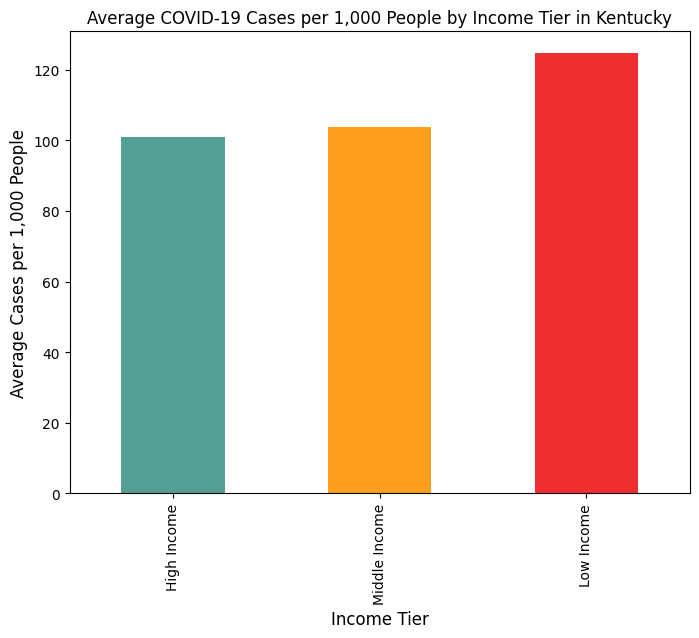

In [360]:
#Create a bar chart showing average COVID-19 cases per 1,000 by income tier
cases_per_1000_by_income = merged_df.groupby('Income_Tier')['cases_per_1000'].mean().sort_values()
colors = ['#549F93', '#FF9F1C', '#EE2E31']
plt.figure(figsize=(8,6))
cases_per_1000_by_income.plot(kind='bar', color=colors)
plt.title('Average COVID-19 Cases per 1,000 People by Income Tier in Kentucky')
plt.xlabel('Income Tier', fontsize=12)
plt.ylabel('Average Cases per 1,000 People', fontsize=12)
plt.show()

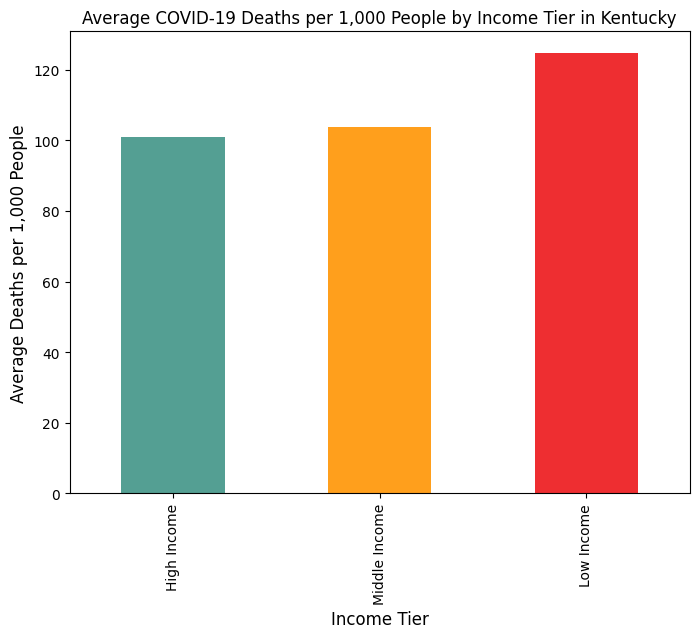

In [361]:
#Create a bar chart showing average COVID-19 deaths per 1,000 by income tier
deaths = merged_df.groupby('Income_Tier')['deaths_per_1000'].mean().sort_values()
colors = ['#549F93', '#FF9F1C', '#EE2E31']
plt.figure(figsize=(8,6))
cases_per_1000_by_income.plot(kind='bar', color=colors)
plt.title('Average COVID-19 Deaths per 1,000 People by Income Tier in Kentucky')
plt.xlabel('Income Tier', fontsize=12)
plt.ylabel('Average Deaths per 1,000 People', fontsize=12)
plt.show()

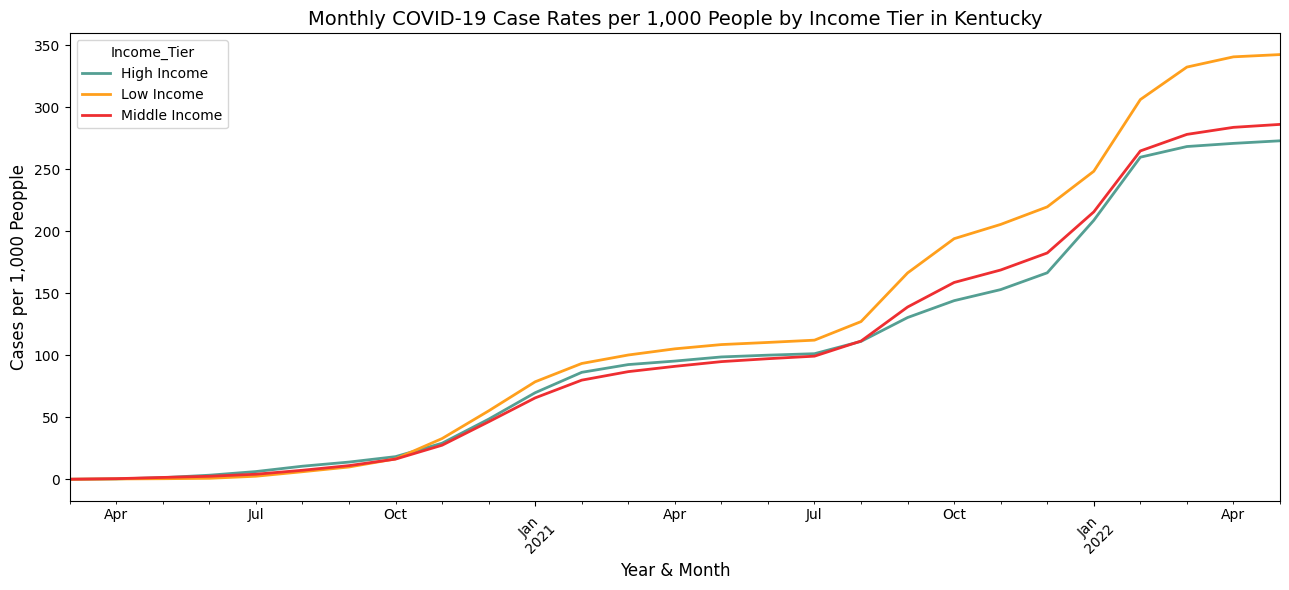

In [362]:
#Creating a line plot to see how COVID-19 case per 1000 vary over time across different income groups 
monthly_cases_per_1000 = merged_df.groupby(['year_month', 'Income_Tier'])['cases_per_1000'].mean().unstack()
monthly_cases_per_1000.plot(kind='line', figsize=(13,6), linewidth=2, color = colors)
plt.title('Monthly COVID-19 Case Rates per 1,000 People by Income Tier in Kentucky', fontsize=14)
plt.xlabel('Year & Month', fontsize=12)
plt.ylabel('Cases per 1,000 Peopple', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

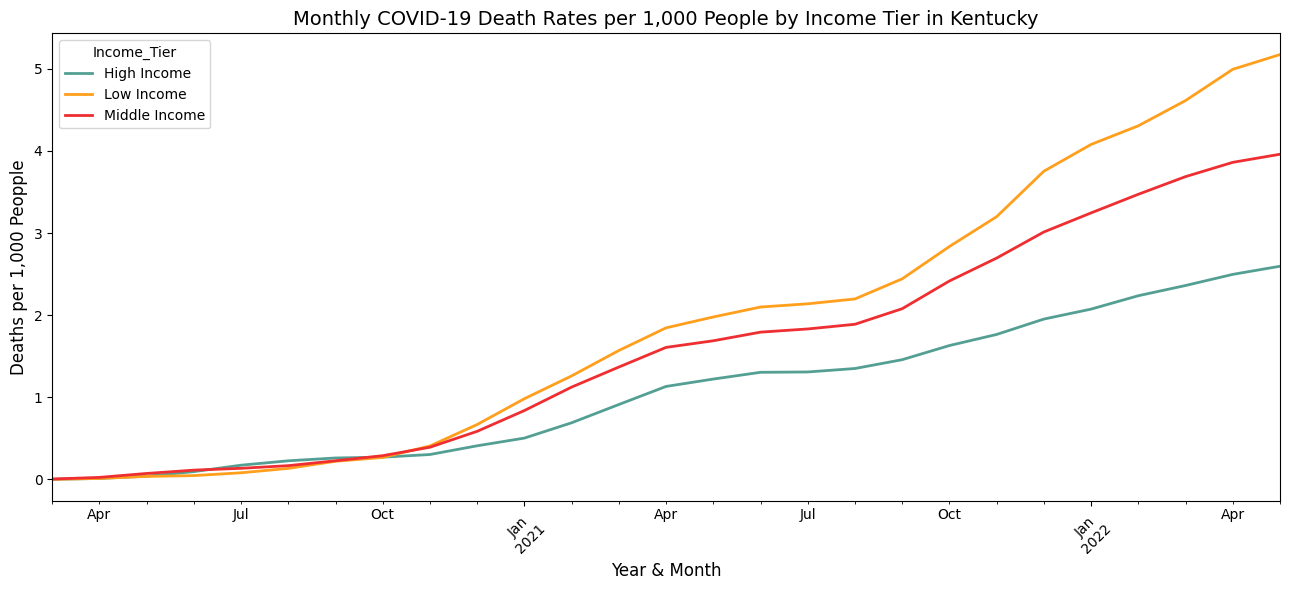

In [363]:
#Creating a line plot to see how COVID-19 deaths per 1000 vary over time across different income groups 
monthly_deaths_per_1000 = merged_df.groupby(['year_month', 'Income_Tier'])['deaths_per_1000'].mean().unstack()
monthly_deaths_per_1000.plot(kind='line', figsize=(13,6), linewidth=2, color = colors)
plt.title('Monthly COVID-19 Death Rates per 1,000 People by Income Tier in Kentucky', fontsize=14)
plt.xlabel('Year & Month', fontsize=12)
plt.ylabel('Deaths per 1,000 Peopple', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

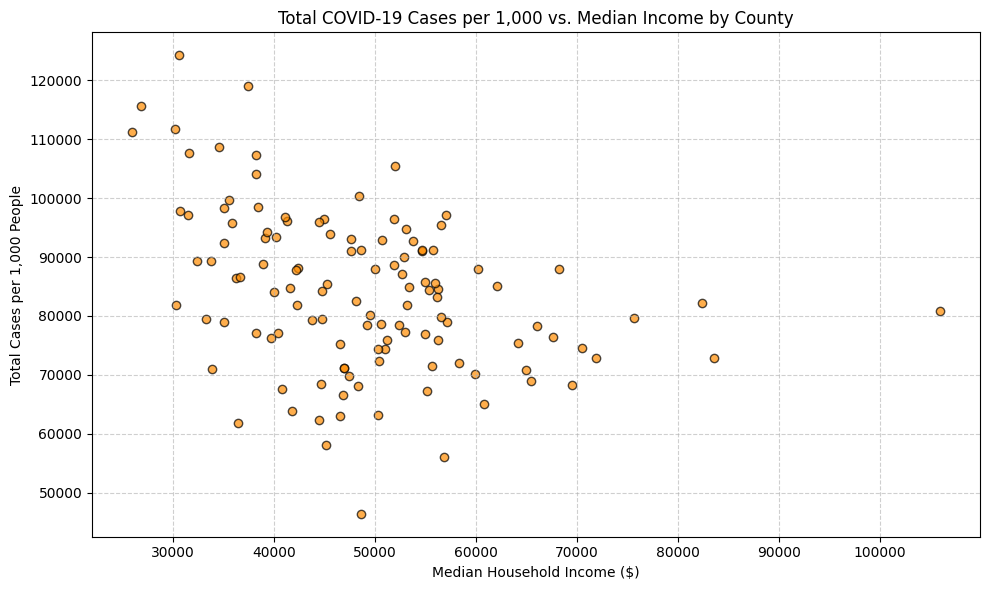

In [364]:
# Aggregate total cases per 1,000 by county
scatter_data = merged_df.groupby('county').agg({
    'cases_per_1000': 'sum',
    'Median Household Income': 'first'  # income is constant per county
}).reset_index()

plt.figure(figsize=(10,6))
plt.scatter(
    scatter_data['Median Household Income'],
    scatter_data['cases_per_1000'],
    color='darkorange', alpha=0.7, edgecolors='black'
)
plt.title('Total COVID-19 Cases per 1,000 vs. Median Income by County')
plt.xlabel('Median Household Income ($)')
plt.ylabel('Total Cases per 1,000 People')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


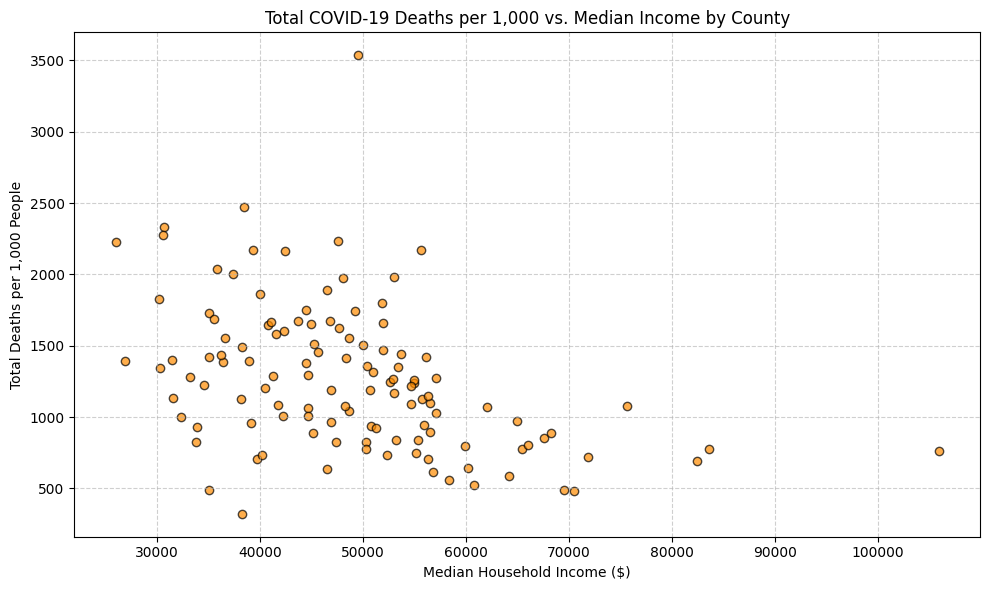

In [366]:
# Aggregate total deaths per 1,000 by county
scatter_data = merged_df.groupby('county').agg({
    'deaths_per_1000': 'sum',
    'Median Household Income': 'first'  
}).reset_index()

plt.figure(figsize=(10,6))
plt.scatter(
    scatter_data['Median Household Income'],
    scatter_data['deaths_per_1000'],
    color='darkorange', alpha=0.7, edgecolors='black'
)
plt.title('Total COVID-19 Deaths per 1,000 vs. Median Income by County')
plt.xlabel('Median Household Income ($)')
plt.ylabel('Total Deaths per 1,000 People')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()